In [1]:
import os
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as TF  # Das fixiert den NameError
import matplotlib.pyplot as plt

# Device Selection (GPU/CPU)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Training auf GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Training auf CPU (Langsam!)")

def read_pfm(file):
    with open(file, "rb") as f:
        header = f.readline().decode('utf-8').rstrip()
        if header == 'PF':
            color = True
        elif header == 'Pf':
            color = False
        else:
            raise Exception('Keine PFM Datei.')

        dims = f.readline().decode('utf-8').split()
        width = int(dims[0])
        height = int(dims[1])

        scale = float(f.readline().decode('utf-8').rstrip())
        # Negativer Scale bedeutet Little Endian (Standard bei SceneFlow)
        if scale < 0:
            endian = '<'
            scale = -scale
        else:
            endian = '>'

        data = np.fromfile(f, endian + 'f')
        shape = (height, width, 3) if color else (height, width)

        data = np.reshape(data, shape)
        data = np.flipud(data) # PFM speichert von unten nach oben
        
        # WICHTIG: Inf-Werte abfangen
        data[data == np.inf] = 0
        
        return data.copy()

    return data

Training auf GPU: NVIDIA GeForce RTX 3080 Ti


In [2]:
class StereoDataset(torch.utils.data.Dataset):
    def __init__(self, left_dir, right_dir, disp_dir, training=True):
        self.left_paths = sorted([os.path.join(left_dir, f) for f in os.listdir(left_dir) if f.endswith('.png')])
        self.right_paths = sorted([os.path.join(right_dir, f) for f in os.listdir(right_dir) if f.endswith('.png')])
        self.disp_paths = sorted([os.path.join(disp_dir, f) for f in os.listdir(disp_dir) if f.endswith('.pfm')])
        
        self.training = training
        self.to_tensor = transforms.ToTensor()
        self.MAX_DISP_TARGET = 192.0
        self.CROP_SIZE = (240, 320)  # (Height, Width) für Chunks
        self.debug_print_done = False

    def __len__(self):
        return len(self.left_paths)

    def augment(self, left, right, disp):
        # Helligkeits-Varianz (Simuliert Sensor-Differenzen)
        if random.random() > 0.2:
            brightness_l = random.uniform(0.95, 1.05)
            brightness_r = random.uniform(0.95, 1.05)
            left = TF.adjust_brightness(left, brightness_l)
            right = TF.adjust_brightness(right, brightness_r)
        return left, right, disp

    def __getitem__(self, idx):
        # 1. Bilder laden (Grayscale für StereoNet)
        left_img = Image.open(self.left_paths[idx]).convert('L')
        right_img = Image.open(self.right_paths[idx]).convert('L')
        
        # 2. Bilder auf Basis-Größe bringen
        left_img = left_img.resize((640, 480), Image.BILINEAR)
        right_img = right_img.resize((640, 480), Image.BILINEAR)
        
        # 3. PFM Disparität laden & skalieren
        disp_np = read_pfm(self.disp_paths[idx])
        disp_np = np.abs(disp_np)
        disp_np[~np.isfinite(disp_np)] = 0
        
        scale_factor = 640.0 / disp_np.shape[1]
        disp = torch.from_numpy(disp_np.copy()).float().unsqueeze(0)
        disp = disp * scale_factor
        disp = F.interpolate(disp.unsqueeze(0), size=(480, 640), mode='nearest').squeeze(0)
        disp = torch.clamp(disp, 0, self.MAX_DISP_TARGET)

        # 4. In Tensoren wandeln
        left_t = self.to_tensor(left_img)
        right_t = self.to_tensor(right_img)

        # 5. RANDOM CROPPING (Nur im Training)
        if self.training:
            # Augmentation vor dem Crop
            left_t, right_t, disp = self.augment(left_t, right_t, disp)
            
            # Koordinaten für den Crop berechnen (identisch für alle Kanäle)
            i, j, h, w = transforms.RandomCrop.get_params(left_t, output_size=self.CROP_SIZE)
            
            left_t = TF.crop(left_t, i, j, h, w)
            right_t = TF.crop(right_t, i, j, h, w)
            disp = TF.crop(disp, i, j, h, w)

        # --- Einmaliger Debug-Print zur Kontrolle ---
        #if not self.debug_print_done:
        #    mode_str = "TRAINING (Chunks)" if self.training else "EVAL (Full-Res)"
        #    print(f"\n{'='*30}\nDEBUG {mode_str}\nShape: {left_t.shape}\n{'='*30}\n")
        #    self.debug_print_done = True

        return left_t, right_t, disp

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 1. HAILO-FRIENDLY RESIDUAL BLOCK (Keep as is, excellent for NPU)
# ============================================================================
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

# ============================================================================
# 2. NPU-OPTIMIZED REFINEMENT (Replacing the heavy Hourglass)
# ============================================================================
class RefinementHead(nn.Module):
    """
    Hierarchical 2D Refinement. 
    Hailo-8 Status: NATIVE (Only 2D Convs, no bottleneck/memory lag)
    """
    def __init__(self, in_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(32, 1, 3, padding=1)
        )

    def forward(self, low_disp, high_res_feat):
        # Resize low-res disparity to high-res target
        up_disp = F.interpolate(low_disp, size=high_res_feat.shape[2:], mode='bilinear', align_corners=False)
        # Cat disparity with features (e.g. Image or intermediate features)
        x = torch.cat([up_disp, high_res_feat], dim=1)
        # Predict residual correction
        return up_disp + self.conv(x)

# ============================================================================
# 3. COST VOLUME (Kept for Geometry Stability)
# ============================================================================
class CostVolumeStridedConv(nn.Module):
    def __init__(self, in_channels, cv_shifts, num_groups):
        super().__init__()
        self.cv_shifts, self.num_groups, self.in_channels = cv_shifts, num_groups, in_channels
        self.shift_conv = nn.Conv2d(in_channels, in_channels * cv_shifts, (1, cv_shifts), groups=in_channels, bias=False)
        self._init_shift_weights()
        self.shift_conv.weight.requires_grad = False
    def _init_shift_weights(self):
        with torch.no_grad():
            self.shift_conv.weight.zero_()
            for c in range(self.in_channels):
                for d in range(self.cv_shifts):
                    self.shift_conv.weight[c * self.cv_shifts + d, 0, 0, self.cv_shifts - 1 - d] = 1.0
    def forward(self, feat_l, feat_r):
        B, C, H, W = feat_l.shape
        feat_r_shifted = self.shift_conv(F.pad(feat_r, (self.cv_shifts - 1, 0, 0, 0), mode='replicate'))
        feat_r_shifted = feat_r_shifted.view(B, C, self.cv_shifts, H, W)
        diff = torch.abs(feat_l.unsqueeze(2) - feat_r_shifted).view(B, self.num_groups, C // self.num_groups, self.cv_shifts, H, W)
        cost = diff.mean(dim=2)
        return cost.reshape(B, self.num_groups * self.cv_shifts, H, W)

# ============================================================================
# 4. FINAL NPU-OPTIMIZED CORE MODEL
# ============================================================================
class StereoNet_NPU_Core(nn.Module):
    def __init__(self, max_disp=192, num_groups=4):
        super().__init__()
        self.max_disp = max_disp
        self.cv_shifts = (max_disp // 4) + 1 # CV on 1/4 resolution
        
        # 1. Feature Extractor (Shared)
        self.init_conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1, bias=False), # 1/2
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.layer_1_4 = ResBlock(32, 32, stride=2) # 1/4
        
        # 2. Cost Volume & Aggregator (1/4 scale)
        self.cost_volume = CostVolumeStridedConv(32, self.cv_shifts, num_groups)
        self.aggregator = nn.Sequential(
            nn.Conv2d(num_groups * self.cv_shifts, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, self.cv_shifts, 3, padding=1)
        )

        # 3. Refinement Heads (Replacing Hourglass)
        self.refine_v1 = RefinementHead(1 + 32) # Scale 1/2 (Disp + 1/2 Features)
        self.refine_v2 = RefinementHead(1 + 1)  # Scale 1/1 (Disp + Image)

        # 4. OCC-Head
        self.register_buffer("disp_range", torch.arange(0, self.cv_shifts).view(1, -1, 1, 1).float())
        self.occ_head = nn.Sequential(
            nn.Conv2d(2, 16, 3, padding=1), # Input: Gray-Image + Disp-Map
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 3, padding=1) # Output: Occlusion-Logits
        )

    def core(self, left, right, training=True, epoch=0):
        # 1. Feature Extraction
        f_l_1_2 = self.init_conv(left)       # 1/2 Auflösung
        f_l_1_4 = self.layer_1_4(f_l_1_2)    # 1/4 Auflösung
        f_r_1_4 = self.layer_1_4(self.init_conv(right))
        
        # 2. 1/4 Disparity Calculation (Soft-Argmax)
        cv = self.cost_volume(f_l_1_4, f_r_1_4)
        cost_scores = self.aggregator(cv)
        prob = F.softmax(-cost_scores, dim=1)
        disp_4 = torch.sum(prob * self.disp_range, dim=1, keepdim=True)
        
        # 3. Scale up to 1/2 and Refine
        # Wir interpolieren auf die Größe der f_l_1_2 Features
        # Wichtig: * 2.0, weil die Auflösung verdoppelt wurde
        disp_low = F.interpolate(disp_4, size=f_l_1_2.shape[2:], mode='bilinear', align_corners=False) * 2.0
        disp_v1 = self.refine_v1(disp_low, f_l_1_2)
        
        # 4. Scale up to 1/1 and Refine
        # Wir interpolieren auf die Originalgröße (left.shape)
        # Wichtig: * 2.0, weil wir von 1/2 auf 1/1 gehen
        disp_v1_up = F.interpolate(disp_v1, size=left.shape[2:], mode='bilinear', align_corners=False) * 2.0
        disp_final = self.refine_v2(disp_v1_up, left)
        
        # 5. Alles für den Loss auf volle Auflösung bringen
        # Falls disp_low noch auf 1/2 ist, hier für den Loss hochziehen
        disp_low_up = F.interpolate(disp_low, size=left.shape[2:], mode='bilinear', align_corners=False) * 2.0
        
        # Occlusion Dummy (muss gleiche Größe wie disp_final haben)
        # 1. Normalisiere die Inputs für den Head (hilft bei der GradNorm)
        norm_img = left # ist bereits [0, 1]
        norm_disp = disp_final / self.max_disp

        # 2. Head berechnen
        occ_in = torch.cat([norm_img, norm_disp], dim=1)
        occ = self.occ_head(occ_in)
        
        # WICHTIG: Da disp_range auf 1/4 Skala basiert (0-48), 
        # haben wir durch die zwei *2.0 Schritte oben bereits die Zielskala (0-192) erreicht!
        # Wir geben die Tensoren jetzt alle in 1/1 Auflösung zurück.
        return disp_final, disp_v1_up, disp_low_up, occ

    def forward(self, left, right, training=False, epoch=0):
        return self.core(left, right, training=training, epoch=epoch)

# ============================================================================
# 5. ALL-MODE WRAPPER (LR + RL Pass)
# ============================================================================
class StereoFusionAllMode(nn.Module):
    def __init__(self, max_disp=192):
        super().__init__()
        self.core = StereoNet_NPU_Core(max_disp=max_disp)

    def forward(self, left, right, mode="fast", epoch=0):
        training_needed = (mode != "fast")
        out_LR = self.core(left, right, training=training_needed, epoch=epoch)
        if mode == "fast": return {"LR": out_LR}
        
        # RL Pass (Flip Symmetry)
        out_RL_f = self.core(torch.flip(right, [3]), torch.flip(left, [3]), training=training_needed, epoch=epoch)
        out_RL = tuple(torch.flip(t, [3]) for t in out_RL_f)
        return {"LR": out_LR, "RL": out_RL}

In [4]:
@torch.no_grad()
def validate(model, val_loader, device):
    model.eval()
    val_loss = 0
    total_epe = 0
    count = 0

    # Fortschrittsbalken für die Validierung
    val_pbar = tqdm(val_loader, desc="🔍 Validierung", leave=False)
    
    with torch.no_grad():
        for left, right, gt in val_pbar:
            left, right, gt = left.to(device), right.to(device), gt.to(device)
            
            mask = gt > 0
            if not mask.any():
                continue

            # Modus "fast" reicht hier völlig aus, da wir nur die LR-Disparität brauchen
            # Das spart ca. 50% Zeit in der Validierung
            outputs = model(left, right, mode="fast")
        
            # Fokus auf finaler LR-Disparität (Subpixel-Resultat)
            # WICHTIG: outputs["LR"] ist jetzt (pred_final, pred_v1, pred_low, occ)
            # Wir validieren gegen den ersten Index [0]
            pred_LR = outputs["LR"][0] 
            pred_LR = torch.clamp(pred_LR, min=0.0)

            # Metriken berechnen
            # L1 Loss als Proxy für die Qualität
            loss = F.l1_loss(pred_LR[mask], gt[mask])
            # EPE (End Point Error) ist der Standard-Maßstab für Stereo-Matching
            epe = torch.abs(pred_LR[mask] - gt[mask]).mean()

            val_loss += loss.item()
            total_epe += epe.item()
            count += 1

            # Anzeige im Balken
            val_pbar.set_postfix({'val_epe': f"{epe.item():.2f}px"})

        avg_loss = val_loss / count if count > 0 else 0
        avg_epe = total_epe / count if count > 0 else 0
        print
    return avg_loss, avg_epe


In [ ]:
import torch.nn.functional as F

import torch.nn.functional as F

def warp(right_img, disp, grid_x=None, grid_y=None):
    """
    Args:
        grid_x, grid_y: Pre-computed grids (optional, für Hailo-Inferenz)
    """
    B, C, H, W = right_img.size()
    
    if grid_x is None or grid_y is None:
        # Training: Erstelle Grids dynamisch
        grid_x, grid_y = torch.meshgrid(
            torch.arange(W, device=right_img.device),
            torch.arange(H, device=right_img.device),
            indexing='xy'
        )
        grid_x = grid_x.unsqueeze(0).expand(B, -1, -1).float()
        grid_y = grid_y.unsqueeze(0).expand(B, -1, -1).float()
    else:
        # Inferenz: Nutze übergebene Grids
        grid_x = grid_x.unsqueeze(0).expand(B, -1, -1)
        grid_y = grid_y.unsqueeze(0).expand(B, -1, -1)

    shifted_x = grid_x - disp.squeeze(1)
    
    # ============ NEU: Subpixel-Toleranz ============
    valid_mask = (shifted_x >= -0.5) & (shifted_x < W - 0.5)
    # ===============================================

    norm_x = 2.0 * shifted_x / (W - 1) - 1.0
    norm_y = 2.0 * grid_y / (H - 1) - 1.0

    vgrid = torch.stack((norm_x, norm_y), dim=3)

    # ============ NEU: Hailo-kompatibles Padding ============
    warped = F.grid_sample(
        right_img, vgrid,
        mode='bilinear',
        padding_mode='border',  # ← Geändert von 'zeros'
        align_corners=False      # ← Geändert von True
    )
    # =======================================================

    return warped, valid_mask.unsqueeze(1).float()


def edge_aware_smoothness_loss(pred_disp, left_img, beta=15.0):
    """
    Beta=15 schützt Kanten radikal. Nur in sehr flachen Bereichen (Gefälle < 1/15)
    wird geglättet. Das verhindert das 'Verwaschen' deiner Stuhlbeine.
    """
    def grad_x(img): return torch.abs(img[:, :, :, :-1] - img[:, :, :, 1:])
    def grad_y(img): return torch.abs(img[:, :, :-1, :] - img[:, :, 1:, :])

    disp_grad_x = grad_x(pred_disp)
    disp_grad_y = grad_y(pred_disp)

    # Graustufen-Gradienten des Referenzbildes
    img_grad_x = grad_x(left_img)
    img_grad_y = grad_y(left_img)

    weight_x = torch.exp(-img_grad_x * beta)
    weight_y = torch.exp(-img_grad_y * beta)

    return (disp_grad_x * weight_x).mean() + (disp_grad_y * weight_y).mean()


def stereo_loss_all_in(outputs_dict, gt, left_img, right_img, 
                       alpha_smooth=0.0, warp_factor=0.0, 
                       lrc_factor=0.0, occ_factor=0.0, rl_geom_factor=0.0):

    (pred_final_LR, pred_v1_LR, pred_low_LR, occ_LR) = outputs_dict["LR"]
    mask = gt > 0
    if not mask.any(): return torch.tensor(0.0, device=gt.device, requires_grad=True), {}

    # 1. DATA LOSS (GT-Anker bleibt die stärkste Kraft)
    def wl1(p, t, m):
        if p.shape != t.shape: p = F.interpolate(p, size=t.shape[2:], mode='bilinear', align_corners=False)
        return F.smooth_l1_loss(p[m], t[m])

    data_LR = 1.0 * wl1(pred_final_LR, gt, mask) + 0.5 * wl1(pred_v1_LR, gt, mask)

    # 2. PHOTOMETRIC (Warping für Subpixel-Genauigkeit)
    warped_L, valid_L = warp(right_img, pred_final_LR)
    # Helligkeitsfehler in Graustufen
    photo_error_map = torch.abs(warped_L - left_img)
    photo_L = (photo_error_map * valid_L).sum() / (valid_L.sum() + 1e-6)
    
    # 3. KANTENSCHUTZ-GLÄTTUNG
    smooth_L = edge_aware_smoothness_loss(pred_final_LR, left_img, beta=15.0)

    # 4. LRC & ECHO-DETEKTION
    lrc_loss = torch.tensor(0.0, device=gt.device)
    data_RL = torch.tensor(0.0, device=gt.device)
    occ_target = torch.zeros_like(occ_LR)

    if "RL" in outputs_dict:
        (pred_final_RL, pred_v1_RL, pred_low_RL, occ_RL) = outputs_dict["RL"]
        gt_f = torch.flip(gt, dims=[3]); mask_f = gt_f > 0
        data_RL = wl1(pred_final_RL, gt_f, mask_f)

        # Geometrischer LRC-Check (Widerspruch Links/Rechts)
        # (Grid-Logik wie in deinem Notebook...)
        # d_R_at_L = F.grid_sample(...)
        lrc_diff = torch.abs(pred_final_LR - d_R_at_L)
        lrc_loss = lrc_diff.mean()

        # ECHO-KILLER LOGIK: 
        # Markiere als Okklusion (hell), wenn Geometrie widersprüchlich (LRC)
        # ODER wenn die gewarpte Graustufe gar nicht zum Original passt (Helligkeits-Fehler > 0.2)
        occ_target = ((lrc_diff > 1.5) | (photo_error_map > 0.2)).float()

    occ_loss = F.binary_cross_entropy_with_logits(occ_LR, occ_target)

    # TOTAL LOSS (Faktoren werden über den Trainer gesteuert)
    total = (data_LR + rl_geom_factor * data_RL + warp_factor * photo_L + 
             alpha_smooth * smooth_L + lrc_factor * lrc_loss + occ_factor * occ_loss)

    return total, {"data_LR": data_LR.item(), "photo_L": photo_L.item(), "lrc": lrc_loss.item(), "occ": occ_loss.item()}

    # 5. OCCLUSION LOSS
    # Wir nutzen LRC-Differenz und Rand-Validierung als Target für den Occ-Head
    if "RL" in outputs_dict:
        occ_target = ((lrc_diff > 1.5) | (lrc_valid_mask == 0)).float()
    else:
        occ_target = torch.zeros_like(occ_LR)

    occ_loss = F.binary_cross_entropy_with_logits(occ_LR, occ_target)

    # 6. FINAL TOTAL LOSS
    total = (data_LR + rl_geom_factor * data_RL + warp_factor * photo_L + 
             alpha_smooth * smooth_L + lrc_factor * lrc_loss + occ_factor * occ_loss)

    logs = {
        "data_LR": data_LR.item(),
        "data_RL": data_RL.item() if "RL" in outputs_dict else 0.0,
        "photo_L": photo_L.item() * warp_factor,
        "lrc": lrc_loss.item() * lrc_factor,
        "occ": occ_loss.item() * occ_factor
    }
    
    return total, logs




import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm.auto import tqdm
import os
import time

def train_production_all_in(model, train_loader, val_loader, test_dataset, device, 
                            epochs=125, lr=1e-4, start_epoch=0, accumulation_steps=16):
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # Scheduler bezieht sich auf die verbleibende Distanz ab start_epoch
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=(epochs-start_epoch), eta_min=1e-6)
    scaler = torch.cuda.amp.GradScaler()

    log_file = "training_log_all_in.txt"
    last_grad_norm = 0.0
    last_damping = 1.0
    warmup_steps = 500

    print(f"🚀 Start All-in Training | Ziel: {epochs} Epochen | Reheat bei 75")
    
    for epoch in range(start_epoch, epochs):
        model.train()
        
        # --- 1. INITIALISIERUNG DER EPOCHEN-STATISTIK (Wichtig!) ---
        epoch_loss = 0.0
        sum_logs = {"data_LR": 0.0, "data_RL": 0.0, "photo_L": 0.0, "lrc": 0.0, "occ": 0.0}
        
        # --- 2. DYNAMISCHE STRATEGIE-PARAMETER ---
        if epoch < 75:
            # Reine Geometrie-Phase
            alpha_smooth, warp_factor, lrc_factor, occ_factor, rl_geom_factor = 0.0, 0.0, 0.0, 0.0, 0.0
        else:
            # ALL-IN PHASE (Start ab 75)
            # progress fadet von 0.1 bis 1.0 über 10 Epochen
            progress = min(1.0, (epoch - 74) / 10.0) 
            alpha_smooth = 0.0005 * progress
            warp_factor = 1.2 * progress
            lrc_factor = 0.3 * progress
            occ_factor = 0.6 * progress
            rl_geom_factor = 0.5 * progress
        
        optimizer.zero_grad()
        pbar = tqdm(train_loader, desc=f"Epoche {epoch+1}/{epochs}", ncols=160)
        
        for batch_idx, (left, right, gt) in enumerate(pbar):
            left, right, gt = left.to(device), right.to(device), gt.to(device)
            
            # Basis-LR vom Scheduler
            scheduled_lr = scheduler.get_last_lr()[0]
            
            # Dynamische Akkumulation
            current_accu = accumulation_steps * 2 if last_grad_norm > 500 else accumulation_steps

            with torch.cuda.amp.autocast():
                # Forward Pass
                out_LR = model.core(left, right)
                if epoch >= 75:
                    l_f, r_f = torch.flip(left, [3]), torch.flip(right, [3])
                    out_RL_f = model.core(r_f, l_f)
                    out_RL = tuple(torch.flip(t, [3]) for t in out_RL_f)
                    outputs = {"LR": out_LR, "RL": out_RL}
                else:
                    outputs = {"LR": out_LR}

                # Loss-Berechnung
                loss, logs = stereo_loss_all_in(outputs, gt, left, right, 
                                                alpha_smooth=alpha_smooth, warp_factor=warp_factor, 
                                                lrc_factor=lrc_factor, occ_factor=occ_factor, 
                                                rl_geom_factor=rl_geom_factor)
                loss_scaled = loss / current_accu

            # Backward
            scaler.scale(loss_scaled).backward()

            # --- 3. OPTIMIZER STEP (NACH AKKUMULATION) ---
            if (batch_idx + 1) % current_accu == 0:
                scaler.unscale_(optimizer)
                
                # Gradient Norm & Damping
                last_grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0).item()
                last_damping = max(0.01, 100.0 / last_grad_norm) if last_grad_norm > 100.0 else 1.0
                
                # LR anpassen
                current_effective_lr = scheduled_lr * last_damping
                for pg in optimizer.param_groups:
                    pg['lr'] = current_effective_lr
                
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            else:
                current_effective_lr = scheduled_lr * last_damping

            # --- 4. STATISTIK UPDATEN ---
            epoch_loss += loss.item()
            for k in sum_logs.keys():
                if k in logs:
                    val = logs[k]
                    sum_logs[k] += val.item() if hasattr(val, 'item') else val

            # Progress Bar mit Damping-Anzeige
            pbar.set_postfix({
                'LR': f"{current_effective_lr:.1e}",
                'Damp': f"{last_damping:.2f}",
                'Grad': f"{last_grad_norm:.1f}",
                'T-EPE': f"{logs.get('data_LR', 0):.2f}px"
            })

        # --- 5. EPOCH END: VALIDIERUNG & LOGGING ---
        val_loss, val_epe = validate(model, val_loader, device)
        scheduler.step()
        
        n_batches = len(train_loader)
        avg_loss = epoch_loss / n_batches
        avg_logs = {k: v / n_batches for k, v in sum_logs.items()}
        
        print(f"📈 Epoche {epoch+1} beendet: Val-EPE: {val_epe:.2f} px")

        with open(log_file, "a") as f:
            # Wir loggen die scheduled_lr (ohne lokales Damping) für die Kurve
            f.write(f"{epoch+1}\t{avg_loss:.4f}\t{val_loss:.4f}\t{val_epe:.4f}\t"
                    f"{avg_logs['data_LR']:.4f}\t{avg_logs['data_RL']:.4f}\t"
                    f"{avg_logs['photo_L']:.4f}\t{avg_logs['lrc']:.4f}\t{avg_logs['occ']:.4f}\t"
                    f"{scheduled_lr:.2e}\t{alpha_smooth}\t{warp_factor}\t{lrc_factor}\t{rl_geom_factor}\n")

        # Visuals & Checkpoint
        save_debug_visuals(model, test_dataset, epoch+1, index=6)
        plot_disparity_profile(model, test_dataset, epoch+1, index=6)
        save_preview(model, test_dataset, f"epoch_{(epoch+1):03d}", index=6, warp_func=warp)
        save_symmetry_comparison(model, test_dataset, device, epoch=epoch, index=6)
        if (epoch + 1) % 5 == 0:
            torch.save(model.state_dict(), f"StereoFusion_ep_{epoch+1}.pth")

    print("✅ Training beendet.")



/home/slarc/miniconda3/envs/stereo_wsl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def save_debug_visuals(model, dataset, epoch, index=0):
    model.eval()

    left, right, gt = dataset[index]
    left  = left.unsqueeze(0).to(device)
    right = right.unsqueeze(0).to(device)

    with torch.no_grad():
        # 1-Pass Forward (wir wollen nur LR)
        out = model(left, right, mode="precise")
        disp_final, disp_v1, disp_low, occ = out["LR"]

    # CPU konvertieren
    disp_final_np = disp_final.squeeze().cpu().numpy()
    disp_v1_np    = disp_v1.squeeze().cpu().numpy()
    disp_low_np   = disp_low.squeeze().cpu().numpy()
    occ_np        = occ.squeeze().cpu().numpy()
    left_np       = left.squeeze().cpu().numpy()
    right_np      = right.squeeze().cpu().numpy()

    # Plotten
    fig, axs = plt.subplots(2, 3, figsize=(14, 8))

    axs[0,0].imshow(left_np, cmap="gray")
    axs[0,0].set_title("Left Image")

    axs[0,1].imshow(right_np, cmap="gray")
    axs[0,1].set_title("Right Image")

    axs[0,2].imshow(disp_low_np, cmap="inferno")
    axs[0,2].set_title("Disp Low")

    axs[1,0].imshow(disp_v1_np, cmap="inferno")
    axs[1,0].set_title("Disp v1")

    axs[1,1].imshow(disp_final_np, cmap="inferno")
    axs[1,1].set_title("Disp Final")

    axs[1,2].imshow(occ_np, cmap="gray")
    axs[1,2].set_title("Occlusion Map")

    for ax in axs.flat:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"training_progress/StereoFusion_debug_epoch_{epoch:03d}.png")
    plt.close()

    
import matplotlib.pyplot as plt

def save_preview(model, dataset, name, index=6, warp_func=None):
    model.eval()
    with torch.no_grad():
        # 1. Daten holen
        left, right, gt = dataset[index]
        left_cuda = left.unsqueeze(0).to(device)
        right_cuda = right.unsqueeze(0).to(device)

        # 2. Precise Mode (LR und RL berechnen)
        outputs = model(left_cuda, right_cuda, mode="precise")
        
        # Tensoren extrahieren (finaler Output ist Index 0)
        disp_LR = outputs["LR"][0].cpu().squeeze()
        disp_RL = outputs["RL"][0].cpu().squeeze()
        
        # 3. Echo-Analyse (LRC-Map)
        # Wir berechnen die Differenz. Wo es hell leuchtet, sind Echos oder Okklusionen.
        echo_map = torch.abs(disp_LR - disp_RL)

        # 4. Plotting
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle(f"Debug Analysis: {name} (Left Edge Echo Check)", fontsize=16)

        # Zeile 1
        axes[0, 0].imshow(left.permute(1, 2, 0).numpy())
        axes[0, 0].set_title("Input Left")
        
        axes[0, 1].imshow(gt.squeeze(), cmap='jet', vmin=0, vmax=192)
        axes[0, 1].set_title("Ground Truth")
        
        im_lr = axes[0, 2].imshow(disp_LR, cmap='jet', vmin=0, vmax=192)
        axes[0, 2].set_title("Prediction LR (Standard)")
        fig.colorbar(im_lr, ax=axes[0, 2])

        # Zeile 2
        im_rl = axes[1, 0].imshow(disp_RL, cmap='jet', vmin=0, vmax=192)
        axes[1, 0].set_title("Prediction RL (Flip-Symmetry)")
        fig.colorbar(im_rl, ax=axes[1, 0])

        # Die Echo-Map zeigt uns das Problem am linken Rand
        im_echo = axes[1, 1].imshow(echo_map, cmap='hot', vmin=0, vmax=20)
        axes[1, 1].set_title("Echo Analysis (LRC-Diff)")
        fig.colorbar(im_echo, ax=axes[1, 1])

        # Fused Output (einfacher Durchschnitt zur Visualisierung)
        fused = (disp_LR + disp_RL) / 2
        axes[1, 2].imshow(fused, cmap='jet', vmin=0, vmax=192)
        axes[1, 2].set_title("Fused Result (Draft)")

        for ax in axes.flatten():
            ax.axis('off')

        plt.tight_layout()
        plt.savefig(f"training_progress/StereoFusion_analysis_{name}.png", bbox_inches='tight')
        plt.close()
        print(f"📸 Analyse-Plot gespeichert: {name}_analysis.png")


def plot_disparity_profile(model, dataset, epoch, index=0):
    model.eval()

    # --- Load sample ---
    left, right, gt = dataset[index]
    left  = left.unsqueeze(0).to(device)
    right = right.unsqueeze(0).to(device)
    gt    = gt.unsqueeze(0).to(device)

    with torch.no_grad():
        # Wir nutzen "precise", um alle Daten (inkl. Occlusion) zu bekommen
        out = model(left, right, mode="precise")
        # Entpacken der LR-Resultate
        disp_final, disp_v1, disp_low, occ_pred = out["LR"]

    # Convert to numpy
    left_np  = left.squeeze().cpu().numpy()
    gt_np    = gt.squeeze().cpu().numpy()
    low_np   = disp_low.squeeze().cpu().numpy()
    v1_np    = disp_v1.squeeze().cpu().numpy()
    final_np = disp_final.squeeze().cpu().numpy()
    
    # Occlusion Map: Sicherstellen, dass sie 2D ist (H, W)
    if occ_pred.dim() == 4: # [B, C, H, W]
        occ_np = occ_pred.squeeze(0).squeeze(0).cpu().numpy()
    else:
        occ_np = occ_pred.squeeze().cpu().numpy()

    H, W = final_np.shape

    # Three profile rows
    rows = [
        int(H * 0.25),
        int(H * 0.50),
        int(H * 0.75)
    ]
    row_labels = ["25% height", "50% height", "75% height"]

    # ---------------------------------------------------------
    # Create a single figure with 4 subplots
    # ---------------------------------------------------------
    # Agg-Backend nutzen (verhindert oft Probleme in Headless-Umgebungen/Notebooks)
    fig, axs = plt.subplots(4, 1, figsize=(14, 20)) 

    # --- Panel 1: Left image with profile lines ---
    axs[0].imshow(left_np, cmap="gray")
    for r in rows:
        axs[0].axhline(r, color="yellow", linewidth=1.5)
    axs[0].set_title(f"Profile Positions – Epoch {epoch}")
    axs[0].axis("off")

    # --- Panels 2–4: One profile per line ---
    for ax, r, label in zip(axs[1:], rows, row_labels):
        # 1. Okklusions-Overlay (Hintergrund)
        ax.fill_between(range(W), 0, 192, where=(occ_np[r, :] > 0.5), 
                        color='red', alpha=0.15, label="Pred. Occlusion (Mask)")

        # 2. Die Disparitäts-Linien
        ax.plot(gt_np[r, :],    color="black",  label="GT (Ground Truth)", linewidth=2.5)
        ax.plot(low_np[r, :],   color="orange", label="disp_low (CostVolume)", alpha=0.6, linestyle='--')
        ax.plot(v1_np[r, :],    color="green",  label="disp_v1 (Refine d=4)", alpha=0.7)
        ax.plot(final_np[r, :], color="red",    label="disp_final (V2 + Photo + LRC)", linewidth=2)

        ax.set_title(
            f"Disparity Profile at {label} (Row {r})\n"
            "Red Shading: Model detected Occlusion/Invalid area"
        )
        ax.set_xlabel("Pixel (X)")
        ax.set_ylabel("Disparity")
        ax.set_ylim(-5, 200) 
        ax.grid(True, which='both', linestyle='--', alpha=0.5)
        ax.legend(loc='upper right', fontsize='small', ncol=2)

    plt.tight_layout()
    
    # Ordner erstellen falls nicht vorhanden
    os.makedirs("training_progress", exist_ok=True)
    
    # Abspeichern
    plt.savefig(f"training_progress/StereoFusion_profile_epoch_{epoch:03d}.png")
    
    # WICHTIG: Speicher freigeben und Anzeige unterdrücken
    plt.close(fig)

def save_symmetry_comparison(model, dataset, device, epoch=0, index=0, save_path=None):
    """
    Erzeugt einen detaillierten Symmetrie-Vergleich ohne Notebook-Output.
    Spalte 1: Normaler Durchlauf (LR)
    Spalte 2: Symmetrischer Durchlauf (RL) - Rohdaten vor dem Back-Flip
    """
    model.eval()
    
    # 1. Daten vorbereiten
    left, right, gt = dataset[index]
    left_t = left.unsqueeze(0).to(device)
    right_t = right.unsqueeze(0).to(device)
    
    with torch.no_grad():
        # LR Pass
        pred_lr, _, _, occ_lr = model.core(left_t, right_t)
        
        # RL Pass (Flipped Inputs)
        left_f = torch.flip(left_t, [3])
        right_f = torch.flip(right_t, [3])
        pred_rl_raw, _, _, occ_rl_raw = model.core(right_f, left_f)
        
        # LRC Differenz berechnen (für die "leuchtenden Zonen")
        # Wir flippen pred_rl_raw zurück, um es mit pred_lr zu vergleichen
        pred_rl_backflipped = torch.flip(pred_rl_raw, [3])
        lrc_diff = torch.abs(pred_lr - pred_rl_backflipped)

    # Hilfsfunktion für Numpy-Konvertierung
    def n(t): return t.squeeze().cpu().numpy()

    # 2. Plotting (8 Panels für maximale Einsicht)
    fig, axes = plt.subplots(4, 2, figsize=(14, 18))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)

    # ZEILE 1: WAS DAS MODELL SIEHT (Inputs)
    axes[0, 0].imshow(n(left_t), cmap='gray')
    axes[0, 0].set_title("Input Links (Original)")
    axes[0, 1].imshow(n(right_f), cmap='gray')
    axes[0, 1].set_title("Input Rechts (Geflippt)")

    # ZEILE 2: VORHERSAGEN (Geometrie)
    vmax = 192 # Skalierung für 640er Breite
    axes[1, 0].imshow(n(pred_lr), cmap='magma', vmin=0, vmax=vmax)
    axes[1, 0].set_title("Prediction LR")
    axes[1, 1].imshow(n(pred_rl_raw), cmap='magma', vmin=0, vmax=vmax)
    axes[1, 1].set_title("Prediction RL (Roh / Geflippt)")

    # ZEILE 3: FEHLER-ANALYSE (LRC & OCC)
    # Hier siehst du die Echos leuchten
    axes[2, 0].imshow(n(lrc_diff), cmap='hot', vmin=0, vmax=20)
    axes[2, 0].set_title("LRC-Differenz (Widerspruch)")
    axes[2, 1].imshow(n(torch.sigmoid(occ_lr)), cmap='gray', vmin=0, vmax=1)
    axes[2, 1].set_title("Occlusion Map (LR Pass)")

    # ZEILE 4: GROUND TRUTH
    axes[3, 0].imshow(n(gt), cmap='magma', vmin=0, vmax=vmax)
    axes[3, 0].set_title("GT Original")
    axes[3, 1].imshow(n(torch.flip(gt.unsqueeze(0), [3])), cmap='magma', vmin=0, vmax=vmax)
    axes[3, 1].set_title("GT Geflippt")

    for ax in axes.ravel():
        ax.axis('off')

    plt.suptitle(f"Symmetrie-Diagnose Epoche {epoch} | Index {index}", fontsize=18)
    
    file_name = save_path or f"symmetry_diag_ep{epoch:03d}_idx{index}.png"
    plt.savefig(file_name, bbox_inches='tight', dpi=150)
    plt.close(fig) # Verhindert Anzeige im Notebook
    print(f"✅ Symmetrie-Debug gespeichert unter: {file_name}")


--- Sanity Check: Index 0 ---
✓ Erfolgreich geladen in 0.0659 Sekunden
✓ Shape Left: torch.Size([1, 240, 320])
✓ Shape Disp: torch.Size([1, 240, 320])
✓ Max Disparität: 55.23 Pixel
✓ Durchschnittliche Tiefe: 20.37 Pixel
✅ Skalierung korrekt: Bereich 0 bis 55.23 Pixel.


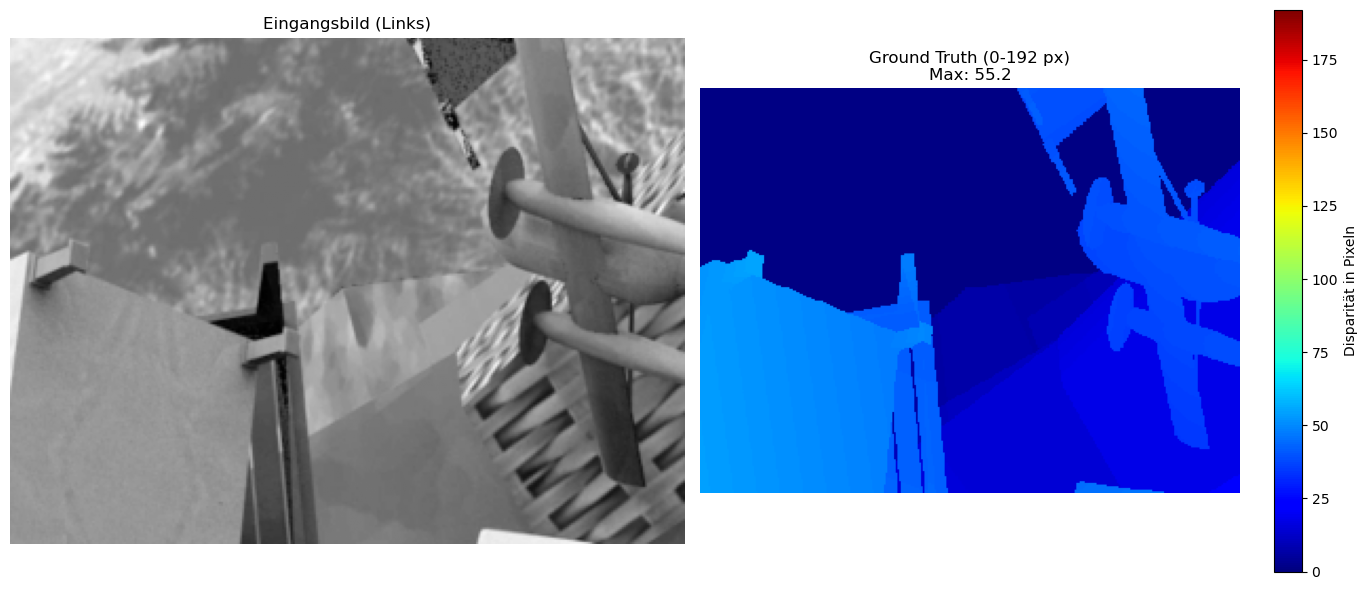

In [7]:
import time
import matplotlib.pyplot as plt

def check_dataset_sanity(dataset, index=0):
    print(f"--- Sanity Check: Index {index} ---")
    start_time = time.time()
    
    try:
        left, right, disp = dataset[index]
        load_time = time.time() - start_time
        
        # Statistiken berechnen
        max_val = disp.max().item()
        mean_val = disp.mean().item()
        
        print(f"✓ Erfolgreich geladen in {load_time:.4f} Sekunden")
        print(f"✓ Shape Left: {left.shape}")
        print(f"✓ Shape Disp: {disp.shape}")
        print(f"✓ Max Disparität: {max_val:.2f} Pixel")
        print(f"✓ Durchschnittliche Tiefe: {mean_val:.2f} Pixel")

        # Validierung der Skalierung
        if max_val <= 1.01:
            print("⚠️ WARNUNG: Die Disparität ist noch auf 0-1 normiert!")
            print("   Stelle sicher, dass Zelle 2 'return left, right, disp_final' (0-192) ausgibt.")
        elif max_val > 192.1:
            print(f"⚠️ WARNUNG: Max Disp ({max_val:.2f}) überschreitet das Limit von 192!")
        else:
            print(f"✅ Skalierung korrekt: Bereich 0 bis {max_val:.2f} Pixel.")

        # Visualisierung
        fig, ax = plt.subplots(1, 2, figsize=(14, 6))
        
        # Eingangsbild
        img_display = left.permute(1, 2, 0).numpy()
        ax[0].imshow(img_display, cmap='gray')
        ax[0].set_title("Eingangsbild (Links)")
        ax[0].axis('off')
        
        # Disparität (Wichtig: vmin/vmax auf den neuen Bereich 0-192)
        im = ax[1].imshow(disp.squeeze().numpy(), cmap='jet', vmin=0, vmax=192)
        ax[1].set_title(f"Ground Truth (0-192 px)\nMax: {max_val:.1f}")
        ax[1].axis('off')
        
        # Farbbalken hinzufügen für besseres Verständnis
        plt.colorbar(im, ax=ax[1], label="Disparität in Pixeln")
        
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"❌ FEHLER beim Laden von Index {index}:")
        import traceback
        traceback.print_exc()

# Aufruf
# check_dataset_sanity(dataset, index=0)
dataset = StereoDataset(
    left_dir='/home/slarc/datasets/sceneflow/left', 
    right_dir='/home/slarc/datasets/sceneflow/right', 
    disp_dir='/home/slarc/datasets/sceneflow/disp'
)

check_dataset_sanity(dataset, index=0)

In [ ]:
def main():
    torch.cuda.empty_cache()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ------------------------------------------------------------
    # 1. Full dataset (training=True enables augmentation)
    # ------------------------------------------------------------
    left_dir='/home/slarc/datasets/sceneflow/left'
    right_dir='/home/slarc/datasets/sceneflow/right'
    disp_dir='/home/slarc/datasets/sceneflow/disp'
    
    full_dataset = StereoDataset(
        left_dir=left_dir,
        right_dir=right_dir,
        disp_dir=disp_dir,
        training=True
    )

    # ------------------------------------------------------------
    # 2. Split into train/val
    # ------------------------------------------------------------
    val_ratio = 0.1
    val_size = int(len(full_dataset) * val_ratio)
    train_size = len(full_dataset) - val_size

    # 1. Erstelle zwei identische Datasets mit unterschiedlichen Flags
    full_data_train = StereoDataset(left_dir, right_dir, disp_dir, training=True)
    full_data_val   = StereoDataset(left_dir, right_dir, disp_dir, training=False)

    # 2. Indizes berechnen (wie vorher)
    dataset_size = len(full_data_train)
    train_size = int(0.9 * dataset_size)
    val_size = dataset_size - train_size

    # 3. Indizes fixieren (WICHTIG: manual_seed für Konsistenz)
    indices = torch.randperm(dataset_size, generator=torch.Generator().manual_seed(42)).tolist()
    train_indices = indices[:train_size]
    val_indices   = indices[train_size:]

    # 4. Subsets erstellen (jetzt greifen sie auf die jeweils richtige Instanz zu)
    train_dataset = torch.utils.data.Subset(full_data_train, train_indices)
    val_dataset   = torch.utils.data.Subset(full_data_val, val_indices)


    # ------------------------------------------------------------
    # 3. DataLoaders
    # ------------------------------------------------------------
    last_epoch = 50
    
    if last_epoch >= 5:
        print("⚠️ RL-Pass aktiv: Schalte in VRAM-Safe-Mode (BS=2, Accu=16)")
        current_bs = 12
        current_accu = 4
    else:
        current_bs = 12
        current_accu = 4
        
    train_loader = DataLoader(
        train_dataset,
        batch_size=current_bs,
        shuffle=True,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=1,
        shuffle=False,
        num_workers=2,
        pin_memory=False,
        prefetch_factor=2
    )

    # ------------------------------------------------------------
    # 4. Test dataset (for previews & profiles)
    # ------------------------------------------------------------
    test_dataset = StereoDataset(
        left_dir='/home/slarc/datasets/sceneflow/left',
        right_dir='/home/slarc/datasets/sceneflow/right',
        disp_dir='/home/slarc/datasets/sceneflow/disp',
        training=False
    )

    # ------------------------------------------------------------
    # 5. Model instantiation
    # ------------------------------------------------------------
    model = StereoFusionAllMode(max_disp=192).to(device)

    # 5.2. BatchNorm Momentum global anpassen
    def set_bn_momentum(model, momentum=0.01):
        for m in model.modules():
            if isinstance(m, torch.nn.BatchNorm2d):
                m.momentum = momentum
        print(f"✅ Alle BatchNorm-Layer auf Momentum {momentum} gesetzt.")

    
    
    # ------------------------------------------------------------
    # 6. Restart logic
    # ------------------------------------------------------------
    
    checkpoint_path = f"StereoFusion_ep_{last_epoch}.pth"

    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path), strict=False)
        print(f"✅ Checkpoint {checkpoint_path} geladen. Wir beheben jetzt das Flächen-Problem.")
    else:
        print(f"⚠️ Achtung: {checkpoint_path} nicht gefunden! Starte bei 0.")
        last_epoch = 0
    
    # ------------------------------------------------------------
    # 7. Training start
    # ------------------------------------------------------------
    # BN momentum Funktion aufrufen
    set_bn_momentum(model, momentum=0.01)
    
    train_production_all_in(
        model,
        device=device,
        train_loader=train_loader,
        val_loader=val_loader,     # <-- NEW
        test_dataset=test_dataset,
        epochs=150,
        lr=1.0e-4,
        start_epoch=last_epoch,
        accumulation_steps=current_accu
    )


if __name__ == '__main__':
    main()




⚠️ RL-Pass aktiv: Schalte in VRAM-Safe-Mode (BS=2, Accu=16)


/tmp/ipykernel_612104/2008631195.py:108: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path), strict=False)
/tmp/ipykernel_612104

✅ Checkpoint StereoFusion_ep_50.pth geladen. Wir beheben jetzt das Flächen-Problem.
✅ Alle BatchNorm-Layer auf Momentum 0.01 gesetzt.
🚀 Start All-in Training (Basis-Accu: 4)


Epoch 51/150:   0%|                                                                                                                         | 0/1955 [00:00<?, ?it/s]/tmp/ipykernel_612104/1363222363.py:237: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 51/150: 100%|████████████████████████████████████████████████████| 1955/1955 [03:35<00:00,  9.08it/s, LR=1.0e-04, Loss=47.195, Grad=55.9, Damp=1.00, VRAM=2.5G]
                                                                                                        

📈 Epoche 51 beendet: Val-Loss: 5.3877 | EPE: 5.39 px
📸 Analyse-Plot gespeichert: epoch_051_analysis.png
✅ Symmetrie-Debug gespeichert unter: symmetry_diag_ep050_idx6.png


...

Epoch 87/150: 100%|████████████████████████████████████████████████████| 1955/1955 [03:33<00:00,  9.16it/s, LR=7.2e-05, Loss=21.135, Grad=42.5, Damp=1.00, VRAM=2.4G]
                                                                                                        

📈 Epoche 87 beendet: Val-Loss: 5.1274 | EPE: 5.13 px
📸 Analyse-Plot gespeichert: epoch_087_analysis.png
✅ Symmetrie-Debug gespeichert unter: symmetry_diag_ep086_idx6.png


Epoch 88/150: 100%|████████████████████████████████████████████████████| 1955/1955 [03:32<00:00,  9.19it/s, LR=7.0e-05, Loss=26.721, Grad=57.0, Damp=1.00, VRAM=2.5G]
                                                                                                        

📈 Epoche 88 beendet: Val-Loss: 5.1349 | EPE: 5.13 px
📸 Analyse-Plot gespeichert: epoch_088_analysis.png
✅ Symmetrie-Debug gespeichert unter: symmetry_diag_ep087_idx6.png


Epoch 89/150:  47%|████████████████████████▊                            | 915/1955 [01:42<01:43, 10.05it/s, LR=6.9e-05, Loss=41.052, Grad=63.8, Damp=1.00, VRAM=2.5G]

In [ ]:
%abort

In [ ]:
import matplotlib.pyplot as plt
full_dataset = StereoDataset(
        left_dir='/home/slarc/datasets/sceneflow/left',
        right_dir='/home/slarc/datasets/sceneflow/right',
        disp_dir='/home/slarc/datasets/sceneflow/disp',
        training=True
    )
val_ratio = 0.1
val_size = int(len(full_dataset) * val_ratio)
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = torch.utils.data.random_split(
        full_dataset,
        [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )

# Ein Bild aus dem Dataset holen
left, right, gt = train_dataset[7491] 

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(left.squeeze(), cmap='gray')
plt.title("Eingangsbild (Ist es aufrecht?)")

plt.subplot(1, 3, 2)
plt.imshow(gt.squeeze(), cmap='jet')
plt.title("GT Disparität")

# Check: Wo sind die Gradienten am stärksten?
# Wenn dy > dx, dann ist die Disparität vertikal orientiert!
dy, dx = torch.gradient(gt.squeeze())
plt.subplot(1, 3, 3)
plt.imshow(dx.abs() > dy.abs(), cmap='gray')
plt.title("Weiß = Horizontale Struktur\nSchwarz = Vertikale Struktur")
plt.show()

In [ ]:
# Testen Sie:
feat = make_feature_extractor()
dummy = torch.randn(1, 1, 480, 640)
out = feat(dummy)
print(f"Feature channels: {out.shape[1]}")  # Muss 32 sein!

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from PIL import Image

# ---------------------------------------------------------
# Hilfsfunktion: Bild laden und normalisieren
# ---------------------------------------------------------
def load_gray_image(path):
    img = Image.open(path).convert("L")
    t = transforms.ToTensor()
    return t(img).unsqueeze(0).cuda()

# Pfade und Device
left_path  = "/home/slarc/datasets/sceneflow/left/0000006.png"
right_path = "/home/slarc/datasets/sceneflow/right/0000006.png"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

left  = load_gray_image(left_path)
right = load_gray_image(right_path)

# Modell laden (Stelle sicher, dass die Klasse definiert ist)
model = StereoFusionAllMode().to(device)
model.eval()

with torch.no_grad():
    # 1. Fast Mode (Nur LR Pass)
    out_fast = model(left, right, mode="fast")
    # Extraktion aus dem Dictionary-Key "LR"
    disp_fast = out_fast["LR"][0]
    occ_fast  = out_fast["LR"][3]

    # 2. Precise Mode (LR und geflippter RL Pass)
    out_prec = model(left, right, mode="precise")
    disp_prec_LR = out_prec["LR"][0]   # Normaler Pass
    disp_prec_RL = out_prec["RL"][0]   # Symmetrischer RL-Pass (bereits zurückgeflippt!)
    
    # Echo-Analyse: Wo unterscheiden sich LR und RL? (Meist am linken Rand)
    echo_map = torch.abs(disp_prec_LR - disp_prec_RL)

# ---------------------------------------------------------
# Visualisierung: Der "Miststück-Check"
# ---------------------------------------------------------
def show_disp(disp, title, subplot_pos, cmap="magma"):
    plt.subplot(2, 2, subplot_pos)
    disp_np = disp.squeeze().cpu().numpy()
    plt.imshow(disp_np, cmap=cmap, vmin=0, vmax=192)
    plt.colorbar(label="Pixel")
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(16, 10))

# Oben Links: Fast Mode (Standard)
show_disp(disp_fast, "Fast Mode (LR only)", 1)

# Oben Rechts: Precise Mode LR
show_disp(disp_prec_LR, "Precise Mode (LR Pass)", 2)

# Unten Links: Precise Mode RL (Der Retter für den linken Rand)
show_disp(disp_prec_RL, "Precise Mode (RL Pass - Flipped)", 3)

# Unten Rechts: Echo-Analyse (LRC-Diff)
# Hier siehst du die Fehler am linken Rand leuchten!
show_disp(echo_map, "Echo Analysis (LRC Diff)", 4, cmap="hot")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# EPE Check
# ---------------------------------------------------------
# Falls gt_disp.npy nicht existiert, erstellen wir eine Dummy-Maske zum Testen
try:
    gt = np.load("gt_disp.npy")
    gt = torch.tensor(gt, dtype=torch.float32).unsqueeze(0).unsqueeze(0).cuda()
    valid = gt > 0
    
    def calc_epe(pred, gt_val, mask):
        return torch.abs(pred - gt_val)[mask].mean().item()

    epe_fast = calc_epe(disp_fast, gt, valid)
    epe_prec = calc_epe(disp_prec_LR, gt, valid)

    print("-" * 30)
    print(f"EPE Fast Mode   : {epe_fast:.4f} px")
    print(f"EPE Precise Mode: {epe_prec:.4f} px")
    print("-" * 30)
except FileNotFoundError:
    print("GT Datei nicht gefunden. Überspringe EPE Check.")


In [ ]:
import torch
from your_model_file import StereoNetLite_GrabberCore

# 1. Load trained model
model = StereoNetLite_GrabberCore(max_disp=192, num_groups=4, input_size=(480, 640))
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

# 2. Create dummy inputs
dummy_left = torch.randn(1, 1, 480, 640)
dummy_right = torch.randn(1, 1, 480, 640)

# 3. Test forward pass
with torch.no_grad():
    output = model(dummy_left, dummy_right, training=False)
    print(f"Output shape: {output.shape}")  # Should be [1, 1, 480, 640]

# 4. Export to ONNX
torch.onnx.export(
    model,
    (dummy_left, dummy_right),
    "stereo_hailo.onnx",
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=['left_image', 'right_image'],
    output_names=['disparity'],
    dynamic_axes={
        'left_image': {0: 'batch_size'},
        'right_image': {0: 'batch_size'},
        'disparity': {0: 'batch_size'}
    }
)

print("✅ ONNX export successful: stereo_hailo.onnx")

# 5. Verify ONNX
import onnx
onnx_model = onnx.load("stereo_hailo.onnx")
onnx.checker.check_model(onnx_model)
print("✅ ONNX model is valid")

# 6. Test ONNX inference
import onnxruntime as ort
session = ort.InferenceSession("stereo_hailo.onnx")
onnx_output = session.run(
    None,
    {'left_image': dummy_left.numpy(), 'right_image': dummy_right.numpy()}
)
print(f"✅ ONNX inference successful, output shape: {onnx_output[0].shape}")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Deine vorhandenen Hilfsfunktionen (PFM & Bilder) ---
def read_pfm(file):
    with open(file, "rb") as f:
        header = f.readline().decode('utf-8').rstrip()
        if header != 'Pf': raise Exception('Keine PFM Pf-Datei.')
        dims = f.readline().decode('utf-8').split()
        width, height = int(dims[0]), int(dims[1])
        scale = float(f.readline().decode('utf-8').rstrip())
        endian = '<' if scale < 0 else '>'
        data = np.fromfile(f, endian + 'f')
        data = np.reshape(data, (height, width))
        data = np.flipud(data)
        data[data == np.inf] = 0
        return data.copy()

# --- 2. Die Analyse-Funktion ---
import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def analyze_checkpoint_pil(checkpoint_path, left_path, right_path, gt_path, row_y=120):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    target_size = (640, 480) # (W, H)
    
    # 1. Modell laden (weights_only=True für Sicherheit)
    model = StereoFusionAllMode().to(device)
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    model.eval()

    # 2. Bilder laden & Resizen (Dein Code)
    left_img_pil = Image.open(left_path).convert('L').resize(target_size, Image.BILINEAR)
    right_img_pil = Image.open(right_path).convert('L').resize(target_size, Image.BILINEAR)
    
    # In Tensor umwandeln [1, 1, 480, 640]
    img_l = torch.from_numpy(np.array(left_img_pil)).float().unsqueeze(0).unsqueeze(0).to(device)
    img_r = torch.from_numpy(np.array(right_img_pil)).float().unsqueeze(0).unsqueeze(0).to(device)

    # 3. Ground Truth laden & Resizen
    gt_orig = read_pfm(gt_path) # Nutzt deine Funktion
    orig_h, orig_w = gt_orig.shape
    
    # WICHTIG: Wenn wir das Bild verkleinern, müssen wir die Disparitätswerte skalieren!
    scale_factor = target_size[0] / orig_w
    gt_rescaled = F.interpolate(torch.from_numpy(gt_orig).unsqueeze(0).unsqueeze(0), 
                                size=(target_size[1], target_size[0]), 
                                mode='nearest').squeeze().numpy()
    gt_rescaled = gt_rescaled * scale_factor # Werte an neue Auflösung anpassen

    # 4. Inferenz
    with torch.no_grad():
        outputs = model(img_l, img_r, mode="precise")
        pred_lr = outputs["LR"][0].cpu().squeeze().numpy()

    # 5. Plotten
    plt.figure(figsize=(15, 6))
    x = np.arange(target_size[0])
    
    plt.plot(x, gt_rescaled[row_y, :], color='black', label='GT (PFM, skaliert)', linewidth=2)
    plt.plot(x, pred_lr[row_y, :], color='red', label='Prediction LR', alpha=0.8)
    
    plt.fill_between(x, gt_rescaled[row_y, :], pred_lr[row_y, :], 
                     where=(np.abs(pred_lr[row_y, :] - gt_rescaled[row_y, :]) > 3),
                     color='red', alpha=0.1, label='Fehler > 3px')

    plt.title(f"Profil-Check Zeile {row_y} (Skalierung: {orig_w} -> {target_size[0]})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Aufruf

# ================================================================
# --- 3. DER FUNKTIONSAUFRUF (HIER PASSIERT ES) ---
# ================================================================

if __name__ == "__main__":
    # Pfade anpassen!
    MY_CHECKPOINT = "StereoFusion_5.pth"
    TEST_L = "/home/slarc/datasets/sceneflow/left/0000052.png"
    TEST_R = "/home/slarc/datasets/sceneflow/right/0000052.png"
    TEST_GT = "/home/slarc/datasets/sceneflow/disp/0000052.pfm"

    # Aufruf für die Problem-Zone (Stuhlbein-Echo oben links)
    analyze_checkpoint(
        checkpoint_path=MY_CHECKPOINT,
        left_path=TEST_L,
        right_path=TEST_R,
        gt_path=TEST_GT,
        row_y=120  # Wähle die Zeile, in der das Stuhlbein im Bild sitzt
    )

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import os
path = '/home/slarc/datasets/sceneflow/disp/' # Update this
print(f"Directory exists: {os.path.exists(path)}")
print(f"Files in directory: {os.listdir(path)[:5]}") # Shows first 5 files

# 1. Function Call
# Replace 'path_to_your_file.pfm' with your actual file path
file_path = '/home/slarc/datasets/sceneflow/disp/disparity_0000000.pfm'
try:
    disparity_map = read_pfm(file_path)
    
    # 2. Visualization
    plt.figure(figsize=(12, 6))
    
    # Use 'magma' or 'plasma' for depth/disparity; it's easier on the eyes
    img = plt.imshow(disparity_map, cmap='magma')
    
    plt.title(f"Stereo Ground Truth Disparity\nResolution: {disparity_map.shape[1]}x{disparity_map.shape[0]}")
    plt.colorbar(img, label='Disparity (pixels)')
    plt.axis('off') # Hide axes for a cleaner look
    
    plt.show()

except FileNotFoundError:
    print(f"Error: The file at {file_path} was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
import os
path = '/mnt/c/temp/sceneflow/disp/' # Update this
print(f"Directory exists: {os.path.exists(path)}")
print(f"Files in directory: {os.listdir(path)[:5]}") # Shows first 5 files